<a href="https://colab.research.google.com/github/yakubavm/monitoring_of_production_processes/blob/LR_1/LR_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from typing import Union, List

# Налаштування глобального стилю для візуалізації даних
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

class ExcelStatsEmulator:
    """
    Клас-інструмент для точного відтворення алгоритмів статистичної обробки MS Excel.
    Використовує параметри ddof=1 (вибіркова дисперсія) та bias=False (незсунені оцінки),
    щоб результати математично збігалися з функціями СТАНДОТКЛОН, СКОС та ЭКСЦЕСС.
    """

    @staticmethod
    def get_descriptive_statistics(data: Union[List[float], np.ndarray], column_name: str = "Значення") -> pd.DataFrame:
        """
        Емулює інструмент "Описательная статистика" з Пакету аналізу MS Excel.
        """
        s = pd.Series(data)

        # Обчислення метрик з урахуванням вибіркових (sample) характеристик
        mean = s.mean()
        std_err = s.sem()
        median = s.median()

        # Обробка моди (може бути декілька значень)
        modes = s.mode()
        mode_val = modes.iloc[0] if not modes.empty else np.nan

        std_dev = s.std(ddof=1)
        variance = s.var(ddof=1)
        kurtosis = s.kurtosis() # Pandas використовує Fisher's kurtosis (bias=False)
        skewness = s.skew()     # Аналогічно для асиметрії

        data_range = s.max() - s.min()
        minimum = s.min()
        maximum = s.max()
        data_sum = s.sum()
        count = s.count()

        # Формування DataFrame у стилістиці звіту Excel
        stats_dict = {
            "Метрика": [
                "Середнє (СРЗНАЧ)", "Стандартна похибка", "Медіана (МЕДИАНА)",
                "Мода (МОДА)", "Стандартне відхилення (СТАНДОТКЛОН)", "Дисперсія вибірки (ДИСП)",
                "Ексцес (ЭКСЦЕСС)", "Асиметрія (СКОС)", "Інтервал",
                "Мінімум", "Максимум", "Сума", "Рахунок"
            ],
            column_name: [
                mean, std_err, median, mode_val, std_dev, variance,
                kurtosis, skewness, data_range, minimum, maximum, data_sum, count
            ]
        }

        return pd.DataFrame(stats_dict).set_index("Метрика")

In [2]:
# Завдання 1: Знайти середнє, медіану, станд. відхилення і квартилі результатів бігу.
print("-" * 50)
print("ВИКОНАННЯ ЗАВДАННЯ 1: Результати бігу на 100 м")
print("-" * 50)

# Вихідний масив даних
run_times = np.array([12.8, 13.2, 13.0, 12.9, 13.5, 13.1, 13.6, 12.7, 12.6, 12.4, 12.5])
run_series = pd.Series(run_times)

# Розрахунок характеристик
mean_time = run_series.mean()
median_time = run_series.median()
std_time = run_series.std(ddof=1) # ddof=1 для вибіркового станд. відхилення

# Обчислення квартилів (Еквівалент КВАРТИЛЬ в Excel)
# Pandas quantile за замовчуванням використовує лінійну інтерполяцію, аналогічно Excel КВАРТИЛЬ.ВКЛ
q1 = run_series.quantile(0.25)
q2 = run_series.quantile(0.50) # Співпадає з медіаною
q3 = run_series.quantile(0.75)

print(f"Середнє значення: {mean_time:.3f} с")
print(f"Медіана:          {median_time:.3f} с")
print(f"Станд. відхилення: {std_time:.3f} с")
print(f"Нижній квартиль (Q1): {q1:.3f} с")
print(f"Медіана (Q2):         {q2:.3f} с")
print(f"Верхній квартиль (Q3): {q3:.3f} с\n")

--------------------------------------------------
ВИКОНАННЯ ЗАВДАННЯ 1: Результати бігу на 100 м
--------------------------------------------------
Середнє значення: 12.936 с
Медіана:          12.900 с
Станд. відхилення: 0.391 с
Нижній квартиль (Q1): 12.650 с
Медіана (Q2):         12.900 с
Верхній квартиль (Q3): 13.150 с



In [3]:
# Завдання 2: Визначити квартилі, вибіркову асиметрію і ексцес для вибірки зросту.
print("-" * 50)
print("ВИКОНАННЯ ЗАВДАННЯ 2: Аналіз варіативності (Зріст)")
print("-" * 50)

# Вихідний масив даних
heights = np.array([164, 160, 157, 166, 162, 160, 161, 159, 160, 163,
                    170, 171, 157, 170, 166, 163, 164, 170, 162])
heights_series = pd.Series(heights)

# Розрахунок характеристик
h_q1 = heights_series.quantile(0.25)
h_q3 = heights_series.quantile(0.75)
# Використовується метод Pandas, який автоматично рахує незсунені (unbiased) оцінки
h_skew = heights_series.skew()
h_kurt = heights_series.kurtosis()

print(f"Нижній квартиль (Q1): {h_q1:.2f}")
print(f"Верхній квартиль (Q3): {h_q3:.2f}")
print(f"Вибіркова асиметрія:  {h_skew:.4f}")
print(f"Вибірковий ексцес:    {h_kurt:.4f}\n")

--------------------------------------------------
ВИКОНАННЯ ЗАВДАННЯ 2: Аналіз варіативності (Зріст)
--------------------------------------------------
Нижній квартиль (Q1): 160.00
Верхній квартиль (Q3): 166.00
Вибіркова асиметрія:  0.4139
Вибірковий ексцес:    -0.8335



In [4]:
# Завдання 3: Знайти найбільш популярний товар (Мода).
print("-" * 50)
print("ВИКОНАННЯ ЗАВДАННЯ 3: Популярність товарів (Мода)")
print("-" * 50)

# Вихідний масив реалізованих товарів
sales = np.array([1, 3, 3, 2, 1, 1, 4, 4, 2, 4, 1, 3, 2, 4, 1,
                  4, 4, 3, 1, 2, 3, 4, 1, 1, 3])
sales_series = pd.Series(sales)

# Визначення моди. Обробляється випадок мультимодальності
modes = sales_series.mode()
modes_list = modes.tolist()

print(f"Реалізовані товари: {sales}")
print(f"Найпопулярніший товар (Мода): {', '.join(map(str, modes_list))}")
print(f"Кількість проданих одиниць цього товару: {sales_series.value_counts()[modes_list[0]]}\n")

--------------------------------------------------
ВИКОНАННЯ ЗАВДАННЯ 3: Популярність товарів (Мода)
--------------------------------------------------
Реалізовані товари: [1 3 3 2 1 1 4 4 2 4 1 3 2 4 1 4 4 3 1 2 3 4 1 1 3]
Найпопулярніший товар (Мода): 1
Кількість проданих одиниць цього товару: 8



In [5]:
# Завдання 4: Описова статистика для концентрації шкідливої речовини.
print("-" * 50)
print("ВИКОНАННЯ ЗАВДАННЯ 4: Пакет аналізу 'Описова статистика'")
print("-" * 50)

# Вихідний масив концентрацій
concentrations = np.array([12, 16, 15, 14, 10, 20, 16, 14, 18, 14, 15, 17, 23, 16, 13])

# Використання раніше створеного архітектурного компонента
desc_stats_df = ExcelStatsEmulator.get_descriptive_statistics(concentrations, column_name="Концентрація (мг/м3)")

# Виведення результату у форматі, ідентичному звіту MS Excel
display(desc_stats_df.round(4))
print("\n")

--------------------------------------------------
ВИКОНАННЯ ЗАВДАННЯ 4: Пакет аналізу 'Описова статистика'
--------------------------------------------------


,Концентрація (мг/м3)
Метрика,
Середнє (СРЗНАЧ),15.5333
Стандартна похибка,0.8215
Медіана (МЕДИАНА),15.0000
Мода (МОДА),14.0000
Стандартне відхилення (СТАНДОТКЛОН),3.1818
Дисперсія вибірки (ДИСП),10.1238
Ексцес (ЭКСЦЕСС),1.2693
Асиметрія (СКОС),0.7240
Інтервал,13.0000


--------------------------------------------------
ВИКОНАННЯ ЗАВДАННЯ 5: Генерація та візуалізація розподілів (Excel RANDBETWEEN)
--------------------------------------------------
Мат. очікування для дискретного діапазону [-1, 1]: -0.0200
Мат. очікування для дискретного діапазону [-2, 2]: -0.1300



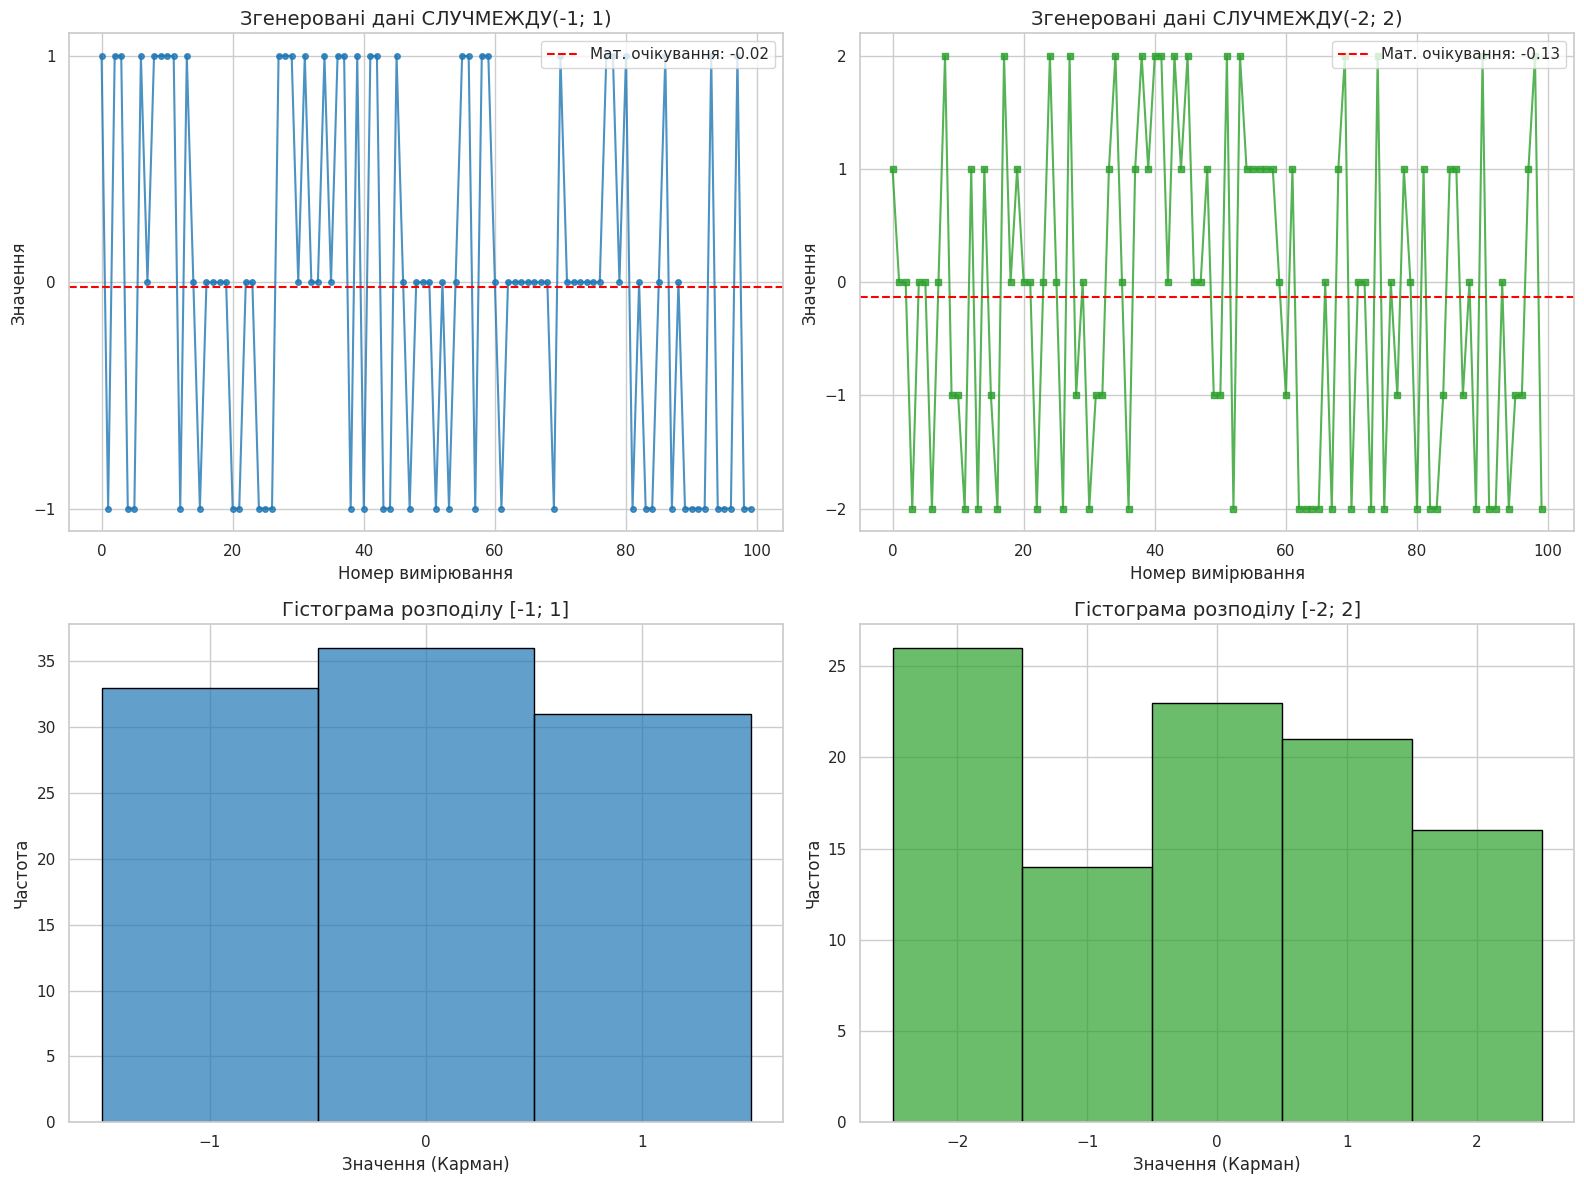

In [6]:
# Завдання 5: Генерація випадкових чисел (Емуляція СЛУЧМЕЖДУ), графіки та гістограми
print("-" * 50)
print("ВИКОНАННЯ ЗАВДАННЯ 5: Генерація та візуалізація розподілів (Excel RANDBETWEEN)")
print("-" * 50)

# Забезпечення відтворюваності результатів (аналог фіксації значень в Excel)
np.random.seed(42)
n_samples = 100

# Використання randint для повної емуляції СЛУЧМЕЖДУ (RANDBETWEEN).
# У numpy.random.randint верхня межа є ексклюзивною, тому для діапазону [-1; 1] вказується 2,
# а для діапазону [-2; 2] вказується 3.
dist_1 = np.random.randint(-1, 2, n_samples)
dist_2 = np.random.randint(-2, 3, n_samples)

# Розрахунок математичного очікування (середнього)
mean_dist_1 = np.mean(dist_1)
mean_dist_2 = np.mean(dist_2)

print(f"Мат. очікування для дискретного діапазону [-1, 1]: {mean_dist_1:.4f}")
print(f"Мат. очікування для дискретного діапазону [-2, 2]: {mean_dist_2:.4f}\n")

# Побудова Dashboard-у з 4 графіків
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Графік 1: Динаміка значень [-1, 1]
axes[0, 0].plot(dist_1, marker='o', linestyle='-', color='#1f77b4', markersize=4, alpha=0.8)
axes[0, 0].set_title("Згенеровані дані СЛУЧМЕЖДУ(-1; 1)")
axes[0, 0].set_xlabel("Номер вимірювання")
axes[0, 0].set_ylabel("Значення")
axes[0, 0].set_yticks([-1, 0, 1]) # Жорстка прив'язка до цілих значень
axes[0, 0].axhline(mean_dist_1, color='red', linestyle='--', label=f'Мат. очікування: {mean_dist_1:.2f}')
axes[0, 0].legend()

# Графік 2: Динаміка значень [-2, 2]
axes[0, 1].plot(dist_2, marker='s', linestyle='-', color='#2ca02c', markersize=4, alpha=0.8)
axes[0, 1].set_title("Згенеровані дані СЛУЧМЕЖДУ(-2; 2)")
axes[0, 1].set_xlabel("Номер вимірювання")
axes[0, 1].set_ylabel("Значення")
axes[0, 1].set_yticks([-2, -1, 0, 1, 2])
axes[0, 1].axhline(mean_dist_2, color='red', linestyle='--', label=f'Мат. очікування: {mean_dist_2:.2f}')
axes[0, 1].legend()

# Графік 3: Гістограма [-1, 1] з налаштуванням "карманів" під дискретні дані
# Для 3-х унікальних значень логічно зробити 3 стовпці (аналог налаштування інтервалу в Excel)
sns.histplot(dist_1, discrete=True, color='#1f77b4', ax=axes[1, 0], edgecolor='black', alpha=0.7)
axes[1, 0].set_title("Гістограма розподілу [-1; 1]")
axes[1, 0].set_xlabel("Значення (Карман)")
axes[1, 0].set_ylabel("Частота")
axes[1, 0].set_xticks([-1, 0, 1])

# Графік 4: Гістограма [-2, 2]
sns.histplot(dist_2, discrete=True, color='#2ca02c', ax=axes[1, 1], edgecolor='black', alpha=0.7)
axes[1, 1].set_title("Гістограма розподілу [-2; 2]")
axes[1, 1].set_xlabel("Значення (Карман)")
axes[1, 1].set_ylabel("Частота")
axes[1, 1].set_xticks([-2, -1, 0, 1, 2])

plt.tight_layout()
plt.show()